In [1]:
%cd ..
from app.data_providers import filtered_shots_dataframe, get_shots_dataframe, main_dataframe
%cd notebooks

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions
/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/notebooks


In [2]:
df = get_shots_dataframe()

Repo card metadata block was not found. Setting CardData to empty.


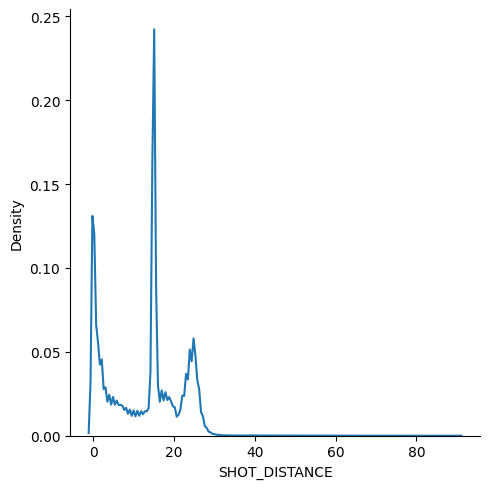

In [4]:
import seaborn as sns
sns.displot(df['SHOT_DISTANCE'], kind = 'kde');

We can clearly see three peaks. These are around 0ft (basket/dunk), 15ft (free throw) and 22ft (3pt line), We have practically (comparatively) no values for above 30ft. This is far from a normal distribution. Of course, there are the lines/peaks introduced by the game rules and then there seems to be a steep decline because players seldomly judge shots to be reasonable above 25, 30ft. There is no gain in points as at the 22ft/3pt line. There is no gain/very little gain in the form of decreased defender density beyond this line, there is also a limit in human strength to shoot the ball at such a distance which adds to the already expected rising imprecision at greater distances.

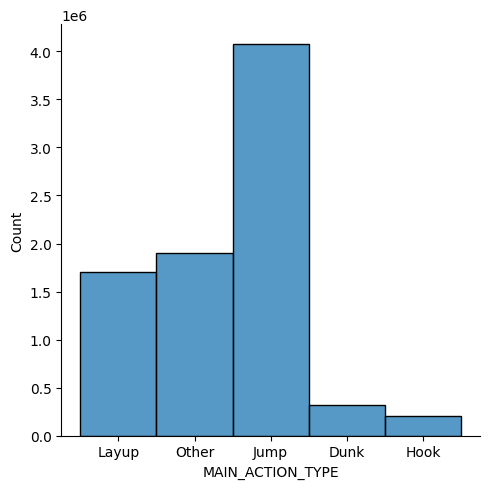

In [5]:
from processing.preprocessing import add_shot_main_action_type_column, add_angle_column, add_is_home_column, \
    add_opponent_interfered_column
df = add_shot_main_action_type_column(df)
sns.displot(df['MAIN_ACTION_TYPE']);

The majority of shots are jump shots. Dunks and hook shots are comparatively rare, but still present enough to work with, since we have several hundred thousand examples. For this plot, we needed to introduce the concept of a "MAIN_ACTION_TYPE" because the raw type is very hard to get an overview over. More time can be invested into analyzing these raw types in detail, because they may reveal information about the difficulty that is lost when grouping. A first thought was that the keyword "fadeaway" might indicate a heightened difficulty that results in a lower success rate.

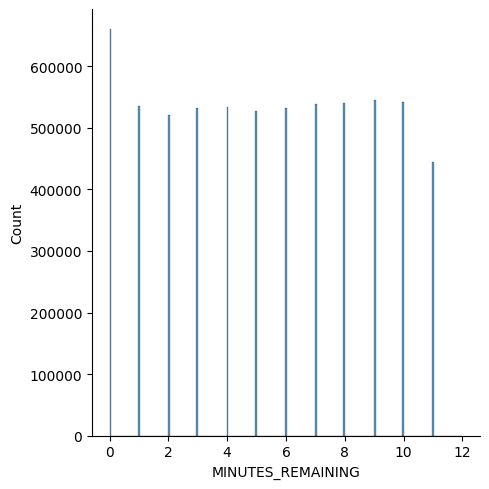

In [8]:
sns.displot(df['MINUTES_REMAINING']);

Shots are distributed quite evenly among the minutes of the period with two exceptions: The first minute (11+ minutes remaining) has slightly less shots, because it begins with the jump-ball and then some time passes before one team can shoot. The last minute seems to imply a lot of literal "last minute shots"

In [9]:
df_filtered_by_players = main_dataframe()

Repo card metadata block was not found. Setting CardData to empty.


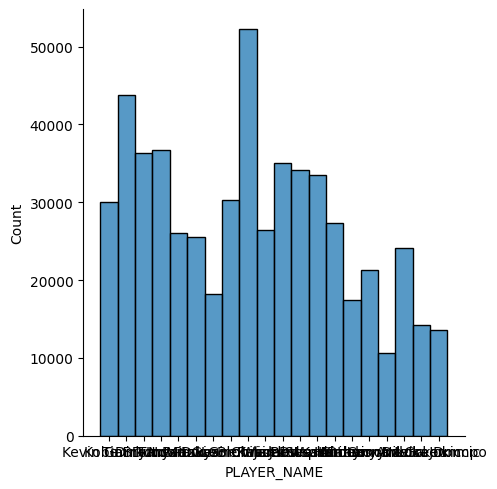

In [10]:
sns.displot(df_filtered_by_players['PLAYER_NAME']);

The players are not evenly distributed, so for some, we have significantly more than others. This will be due to their nba career start relative to the datasets timeframe and role in the team. 